# Load dpca results 2

In [6]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("../../")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import load
import matplotlib.cm as cm


from tools.params import Params
import tools.dimensionality.dpca as dim
import tools.viz.utilityTools as vizutils

RUN_TAG = "lpt_rauto_k10"   # <-- the run-tag folder to visualize
RUN_DIR = Params.ACROSS_SESSION_RESULTS_DIR / "kinematic-dpca-noisefloor" / RUN_TAG
print(RUN_DIR)
print(sorted(p.name for p in RUN_DIR.glob("*")))

# # marginalisation colours: time grey, level red, angle ('p') blue, interactions purple
GREY, RED, BLUE, PURPLE = "#9C9C9C", "#BB1419", "#0091E6", "#6B5BA1"


def marg_color(key):
    factors = set(key) - {"t"}
    if not factors:             # pure time / condition-independent
        return GREY
    if factors == {"l"}:        # level x time
        return RED
    if len(factors) == 1:       # a single non-level factor (angle 'p' / axis / direction)
        return BLUE
    return PURPLE               # any interaction (>1 factor)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/kinematic-dpca-noisefloor/lpt_rauto_k10
['M061_2025_03_04_10_00.npz', 'M061_2025_03_04_10_00_fit.joblib', 'M061_2025_03_05_14_00.npz', 'M061_2025_03_05_14_00_fit.joblib', 'M061_2025_03_06_14_00.npz', 'M061_2025_03_06_14_00_fit.joblib', 'M062_2025_03_20_14_00.npz', 'M062_2025_03_20_14_00_fit.joblib', 'M062_2025_03_21_14_00.npz', 'M062_2025_03_21_14_00_fit.joblib', 'M078_2025_08_06_15_00.npz', 'M078_2025_08_06_15_00_fit.joblib', 'M086_2025_12_10_15_00.npz', 'M086_2025_12_10_15_00_fit.joblib', 'M103_2026_02_18_15_30.npz', 'M103_2026_02_18_15_30_fit.joblib', 'M103_2026_02_19_15_30.npz', 'M103_2026_02_19_15_30_fit.joblib', 'M106_2026_02_25_15_00.npz', 'M106_2026_02_25_15_00_fit.joblib', 'summary.csv']


In [208]:
sess = 'M061_2025_03_06_14_00'
b = load(RUN_DIR / f"{sess}_fit.joblib")
m, X, cond_values, trialX = b["dpca"], b["X_psth"], b["cond_values"], b["trialX"]
feat = np.load(Params.ACROSS_SESSION_RESULTS_DIR / "cache" / f"{sess}.npz",
               allow_pickle=True)["labels"]
keys = ['t', 'lt', 'pt', 'lpt']
Zc = m.transform(X)                                       # key -> (n_comp, n_level, n_angle, n_time)
t = np.arange(X.shape[-1]) / 100 - 0.5   


## Energy plots

In [117]:
def energy_for_marg(marg):
    Z_marg = Zc[marg].reshape(Zc[marg].shape[0], -1, Zc[marg].shape[-1])
    w = np.tensordot(m.P[marg], Z_marg, axes=([1], [0]))
    return (w ** 2).mean(axis=1)


In [109]:
kp_of  = np.array([f.rsplit("_", 1)[0] for f in feat])
dim_of = np.array([f.rsplit("_", 1)[1] for f in feat])

FORE  = {"left_elbow", "left_wrist", "left_paw", "right_elbow", "right_wrist", "right_paw"}
HIND  = {"left_ankle", "left_knee", "left_foot", "right_ankle", "right_knee", "right_foot"}
AXIAL = {"tail_base", "tail_middle", "tail_tip", "hip_center", "shoulder_center",
         "left_shoulder", "right_shoulder"}
groups = {"forelimb": np.isin(kp_of, list(FORE)),
          "hindlimb": np.isin(kp_of, list(HIND)),
          "axial":    np.isin(kp_of, list(AXIAL))}

dim_cols = ["rc", "vt", "ml"]

In [110]:
e_fore.shape

(6, 200)

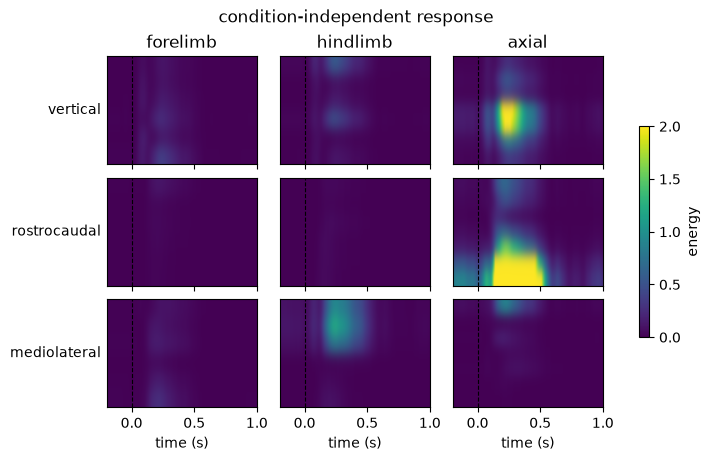

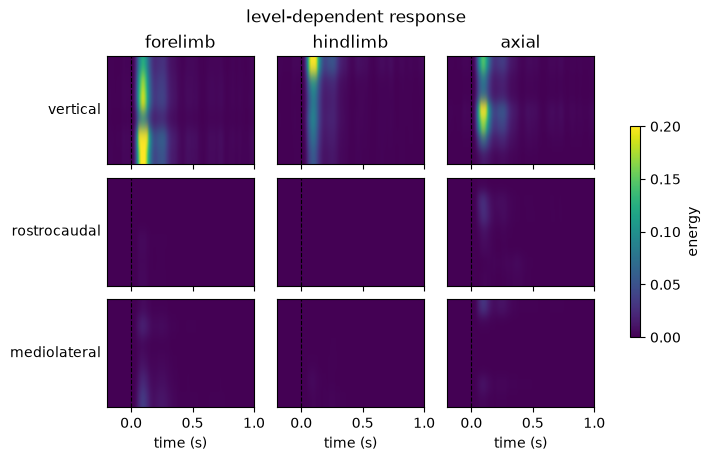

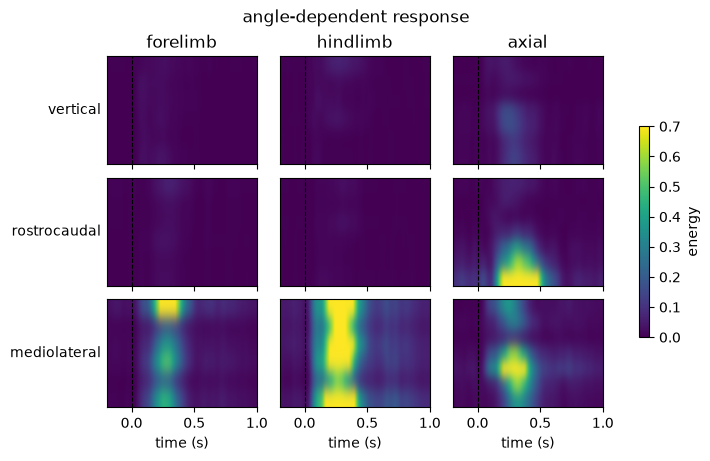

In [124]:
group_names = ['forelimb', 'hindlimb', 'axial']
dim_names = ['vt', 'rc', 'ml']
dim_labels = {'vt': 'vertical', 'rc': 'rostrocaudal', 'ml': 'mediolateral'}

marg_titles = {'t': 'condition-independent response', 'lt': 'level-dependent response', 'pt': 'angle-dependent response'}


def plot_marg_heatmaps(marg, vmax, vmin=0):
    energy_cond = energy_for_marg(marg)
    data = {
        g: {d: energy_cond[groups[g] & (dim_of == d)] for d in dim_names}
        for g in group_names
    }

    fig, axs = plt.subplots(
        len(dim_names), len(group_names), figsize=(7, 4.5),
        sharex='all', constrained_layout=True,
        gridspec_kw={'hspace': 0.05, 'wspace': 0.05},
    )

    for col, g in enumerate(group_names):
        for row, d in enumerate(dim_names):
            arr = data[g][d]
            ax = axs[row, col]
            im = ax.imshow(arr, extent=[t[0], t[-1], arr.shape[0], 0], aspect='auto',
                           interpolation='gaussian', vmin=vmin, vmax=vmax)
            ax.axvline(0, color='k', lw=0.8, ls='--')  # perturbation onset
            ax.set_yticks([])
            if row == 0:
                ax.set_title(g)
            if col == 0:
                ax.set_ylabel(dim_labels[d], rotation=0, ha='right', va='center')
            if row == len(dim_names) - 1:
                ax.set_xlabel('time (s)')

    axs[0, 0].set_xlim(-0.2, 1)
    fig.colorbar(im, ax=axs, label='energy', shrink=0.6)
    fig.suptitle(marg_titles[marg])
    return fig, axs


VMAX = {'t': 2, 'lt': .2, 'pt': 0.7}  # <-- set per-marginalization color-scale max here

for marg in ['t', 'lt', 'pt']:
    plot_marg_heatmaps(marg, vmax=VMAX[marg])


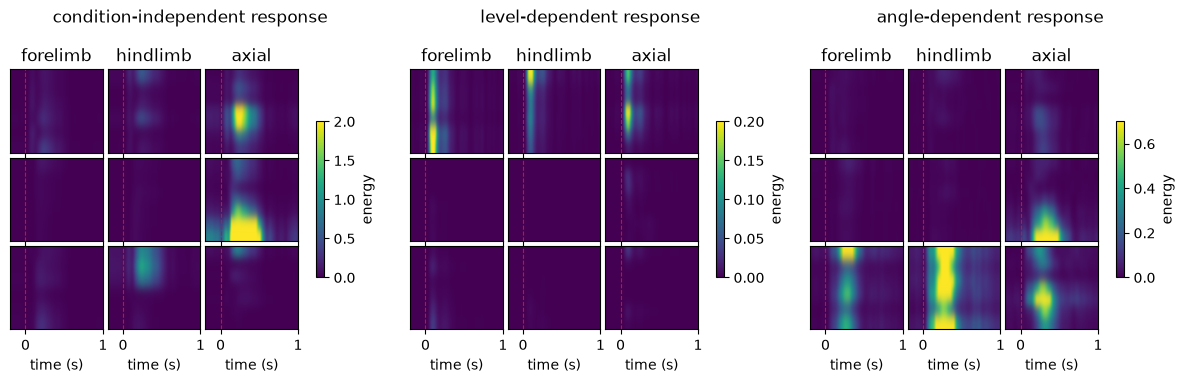

In [159]:
margs = ['t', 'lt', 'pt']

fig = plt.figure(figsize=(12, 4), constrained_layout=False)
subfigs = fig.subfigures(1, len(margs), wspace=0.0)

for i, (subfig, marg) in enumerate(zip(subfigs, margs)):
    energy_cond = energy_for_marg(marg)
    data = {
        g: {d: energy_cond[groups[g] & (dim_of == d)] for d in dim_names}
        for g in group_names
    }
    vmax = VMAX[marg]

    axs = subfig.subplots(
        len(dim_names), len(group_names),
        sharex='all', gridspec_kw={'hspace': 0.05, 'wspace': 0.05},
    )
    subfig.subplots_adjust(left=0.05, right=0.95, top=0.8, bottom=0.15)

    for col, g in enumerate(group_names):
        for row, d in enumerate(dim_names):
            arr = data[g][d]
            ax = axs[row, col]
            im = ax.imshow(arr, extent=[t[0], t[-1], arr.shape[0], 0], aspect='auto',
                           interpolation='gaussian', vmin=0, vmax=vmax)
            ax.axvline(0, color='r', lw=0.8, ls='--')  # perturbation onset
            ax.set_yticks([])
            if row == 0:
                ax.set_title(g, y=1)
            # if col == 0 and i == 0:
            #     ax.set_ylabel(dim_labels[d], rotation=0, ha='right', va='center')
            if row == len(dim_names) - 1:
                ax.set_xlabel('time (s)')

    axs[0, 0].set_xlim(-0.2, 1)
    subfig.colorbar(im, ax=axs, label='energy', shrink=0.6)
    subfig.suptitle(marg_titles[marg], y=0.95)


In [169]:
# fig, ax = plt.subplots()
energy_cond = energy_for_marg('lt')
data_lt = {
        g: {d: energy_cond[groups[g] & (dim_of == d)] for d in dim_names}
        for g in group_names
    }
energy_cond = energy_for_marg('pt')
data_pt = {
        g: {d: energy_cond[groups[g] & (dim_of == d)] for d in dim_names}
        for g in group_names
    }

Text(0.5, 1.0, 'Energy in keypoint x marginalization')

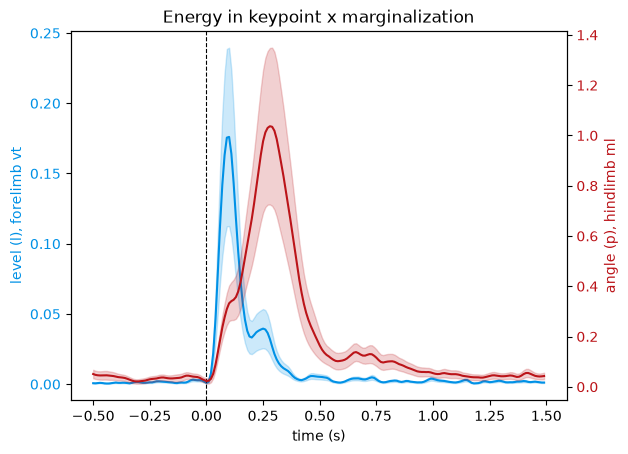

In [176]:
fig, ax = plt.subplots()
ax2 = ax.twinx()

vizutils.shaded_errorbar(ax, t, data_lt['forelimb']['vt'].T, color="#0091E6")
vizutils.shaded_errorbar(ax2, t, data_pt['hindlimb']['ml'].T, color="#BB1419")

ax.set_ylabel('level (l), forelimb vt', color="#0091E6")
ax2.set_ylabel('angle (p), hindlimb ml', color="#BB1419")
ax.tick_params(axis='y', labelcolor="#0091E6")
ax2.tick_params(axis='y', labelcolor="#BB1419")
ax.set_xlabel('time (s)')
ax.axvline(0, color='k', lw=0.8, ls='--')  # perturbation onset
ax.set_title('Energy in keypoint x marginalization')


## Single trials

In [211]:

def drop_nan_trials(trialX):
    """Drop padded trial slots (all-NaN across features/time) from trialX.

    trialX: (n_trial, n_features, n_level, n_angle, n_time)
    Returns a boolean valid-trial mask of shape (n_trial, n_level, n_angle)
    and, if you want a flat list per condition, a dict of arrays.
    """
    valid = ~np.isnan(trialX).all(axis=(1, 4))  # (n_trial, n_level, n_angle)
    return valid

In [212]:
mask = drop_nan_trials(trialX)
trial_i, level_i, angle_i = np.where(mask)
trials = trialX[trial_i, :, level_i, angle_i, :]   # (n_valid, n_features, n_time)
trials.shape


(208, 57, 200)

In [222]:
marg = 'pt'

# projects directly on the real feature axis (trials.shape[1]) -- no reshape needed
proj = np.tensordot(m.P[marg], trials, axes=([0], [1]))   # (n_comp, n_valid_trials, n_time)


In [223]:
proj.shape

(10, 208, 200)

In [227]:
b.keys()

dict_keys(['dpca', 'X_psth', 'trialX', 'codes', 'cond_values', 'config'])

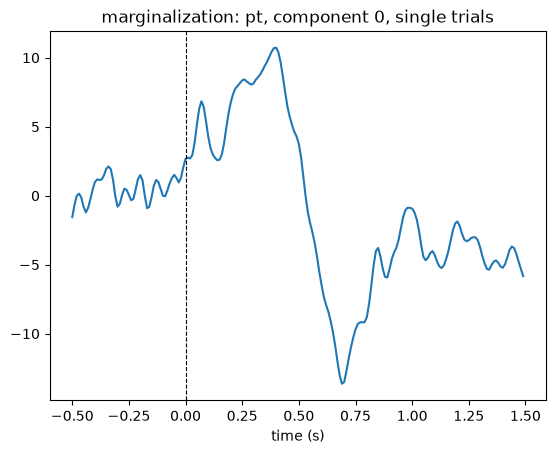

In [230]:
plt.plot(t, proj[0, 1, :])
plt.axvline(0, color='k', lw=0.8, ls='--')  # perturbation onset
plt.xlabel('time (s)')
plt.title(f'marginalization: {marg}, component 0, single trials')
plt.show()
